In [ ]:
# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic
#                         Regression).


===== Ridge Regression Results =====
Average Training R2: 0.7875588946022193
Average Validation R2: 0.762565018552025
Average Training MSE: 29.206320108222343
Average Validation MSE: 30.448070297200047

===== Logistic Regression (Pass/Fail) =====
Average Training Accuracy: 0.9212499999999999
Average Validation Accuracy: 0.9099999999999999
Average Validation F1 Score: 0.949968082467407


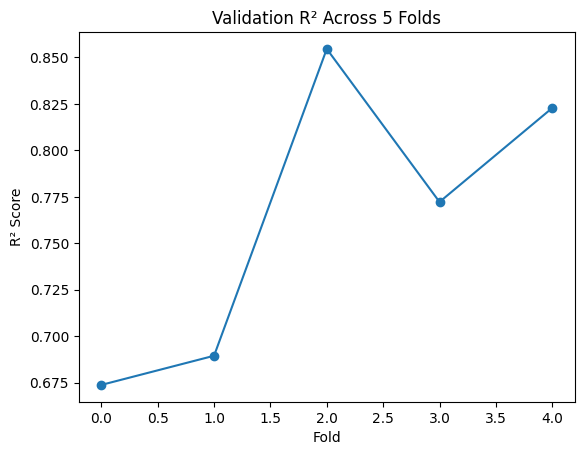

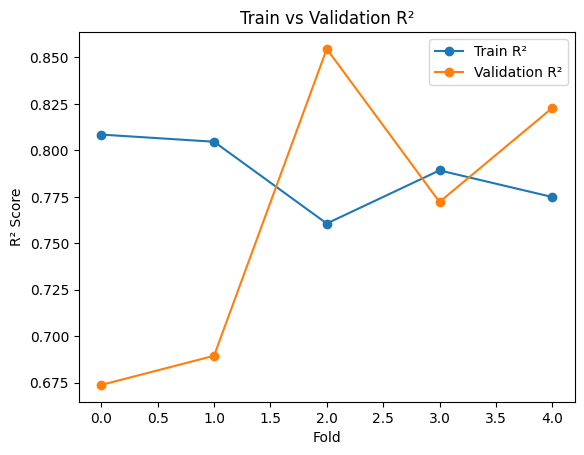

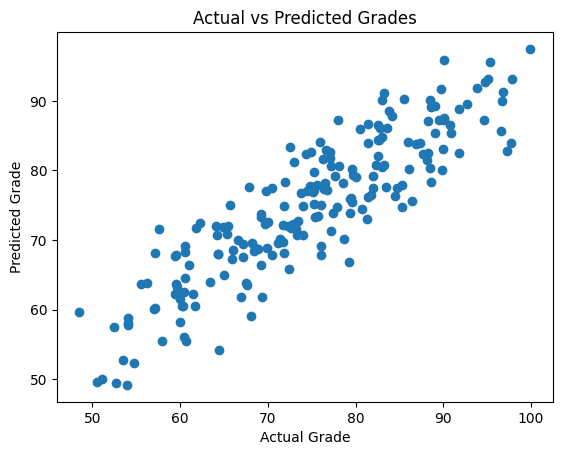

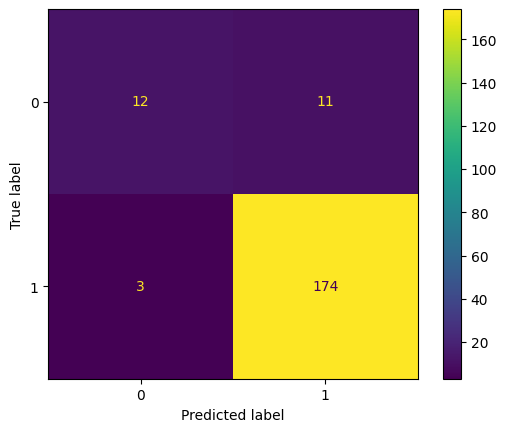

In [2]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ==============================
# 2. Create Sample Dataset
# (200 students)
# ==============================

np.random.seed(42)

n = 200

data = pd.DataFrame({
    "study_hours": np.random.randint(2, 20, n),
    "attendance": np.random.randint(50, 100, n),
    "previous_score": np.random.randint(40, 100, n),
    "sleep_hours": np.random.uniform(4, 9, n),
})

# Generate target grade (regression target)
data["grade"] = (
    0.4 * data["study_hours"]
    + 0.3 * data["attendance"]
    + 0.5 * data["previous_score"]
    + 2 * data["sleep_hours"]
    + np.random.normal(0, 5, n)
)

# Classification target (Pass/Fail)
data["pass_fail"] = (data["grade"] >= 60).astype(int)

X = data[["study_hours", "attendance", "previous_score", "sleep_hours"]]
y_reg = data["grade"]
y_clf = data["pass_fail"]

# ==============================
# 3. Ridge Regression Pipeline
# ==============================

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# ==============================
# 4. K-Fold Cross Validation (Regression)
# ==============================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "mse": "neg_mean_squared_error"
}

cv_results = cross_validate(
    ridge_pipeline,
    X,
    y_reg,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

# ==============================
# 5. Display Results
# ==============================

print("\n===== Ridge Regression Results =====")

print("Average Training R2:",
      np.mean(cv_results["train_r2"]))

print("Average Validation R2:",
      np.mean(cv_results["test_r2"]))

print("Average Training MSE:",
      -np.mean(cv_results["train_mse"]))

print("Average Validation MSE:",
      -np.mean(cv_results["test_mse"]))


# ==============================
# 6. Stratified K-Fold (Classification)
# ==============================

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression())
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_results = cross_validate(
    log_reg_pipeline,
    X,
    y_clf,
    cv=skf,
    scoring=["accuracy", "f1"],
    return_train_score=True
)

print("\n===== Logistic Regression (Pass/Fail) =====")

print("Average Training Accuracy:",
      np.mean(clf_results["train_accuracy"]))

print("Average Validation Accuracy:",
      np.mean(clf_results["test_accuracy"]))

print("Average Validation F1 Score:",
      np.mean(clf_results["test_f1"]))

plt.figure()
plt.plot(cv_results["test_r2"], marker='o')
plt.title("Validation R² Across 5 Folds")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.show()


plt.figure()
plt.plot(cv_results["train_r2"], label="Train R²", marker='o')
plt.plot(cv_results["test_r2"], label="Validation R²", marker='o')

plt.title("Train vs Validation R²")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.legend()
plt.show()


ridge_pipeline.fit(X, y_reg)
pred = ridge_pipeline.predict(X)

plt.figure()
plt.scatter(y_reg, pred)
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Grades")
plt.show()


log_reg_pipeline.fit(X, y_clf)
ConfusionMatrixDisplay.from_estimator(log_reg_pipeline, X, y_clf)
plt.show()

In [ ]:
# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

R² Scores per Fold: [0.88050829 0.89357439 0.9128554  0.88616291 0.86999241]
Average R²: 0.8886186796293731


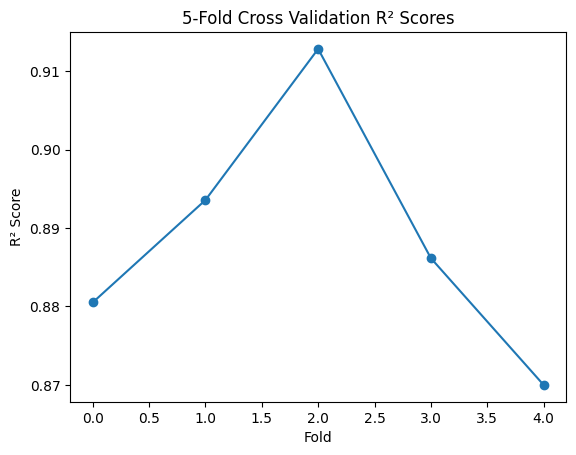

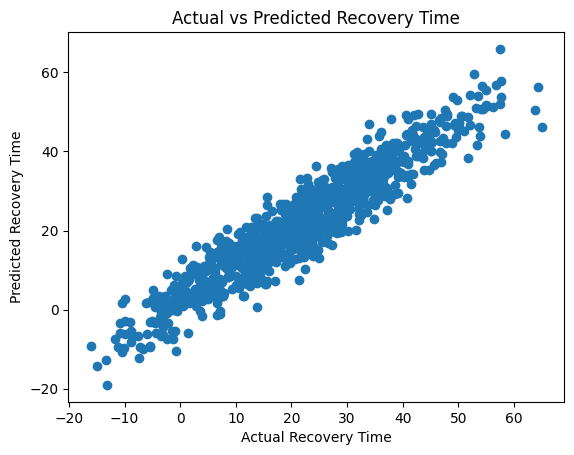

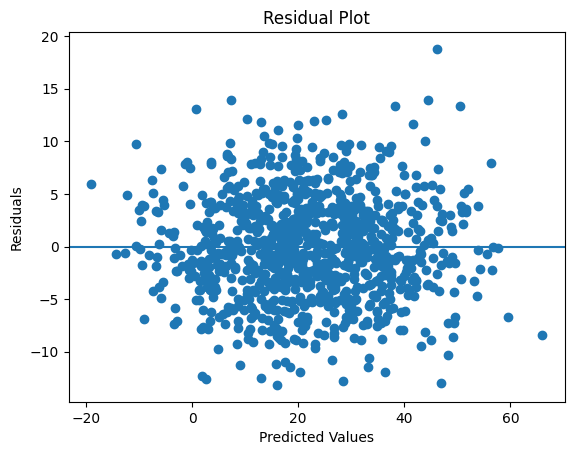

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "age": np.random.randint(20, 80, n),
    "physiotherapy_hours": np.random.uniform(1, 10, n),
    "health_severity": np.random.uniform(1, 10, n),
    "hospital_stay": np.random.randint(2, 20, n),
    "sleep_hours": np.random.uniform(4, 9, n)
})

# Target: Recovery Time (days)
data["recovery_time"] = (
    0.3 * data["age"]
    - 2.5 * data["physiotherapy_hours"]
    + 3 * data["health_severity"]
    + 1.5 * data["hospital_stay"]
    - 1.8 * data["sleep_hours"]
    + np.random.normal(0, 5, n)
)

X = data.drop("recovery_time", axis=1)
y = data["recovery_time"]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R² Scores per Fold:", r2_scores)
print("Average R²:", np.mean(r2_scores))


plt.figure()
plt.plot(r2_scores, marker='o')
plt.title("5-Fold Cross Validation R² Scores")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.show()

y_pred = cross_val_predict(model, X, y, cv=kf)

plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Actual Recovery Time")
plt.ylabel("Predicted Recovery Time")
plt.title("Actual vs Predicted Recovery Time")
plt.show()

residuals = y - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



In [ ]:
# Scenario: Predicting Student Exam Performance
# A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
# - Number of study hours per week
# - Attendance percentage in lectures
# - Prior GPA (Grade Point Average)
# - Participation in group projects (numeric engagement score)
# - Average sleep hours during exam preparation
# They collect data from 800 students across different departments and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

R² Score per Fold: [0.89785793 0.91124026 0.91028971 0.9011506  0.91088558]
Average R²: 0.9062848151651917


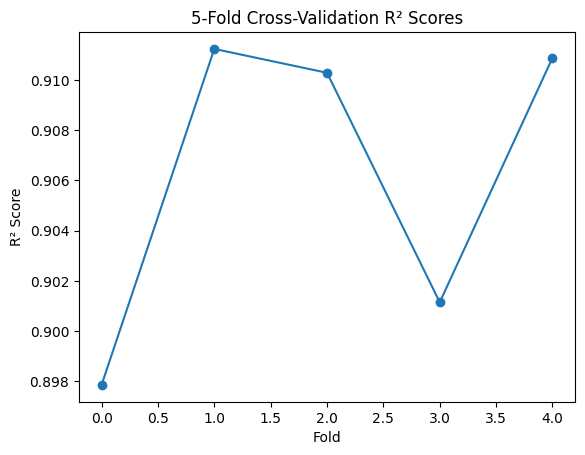

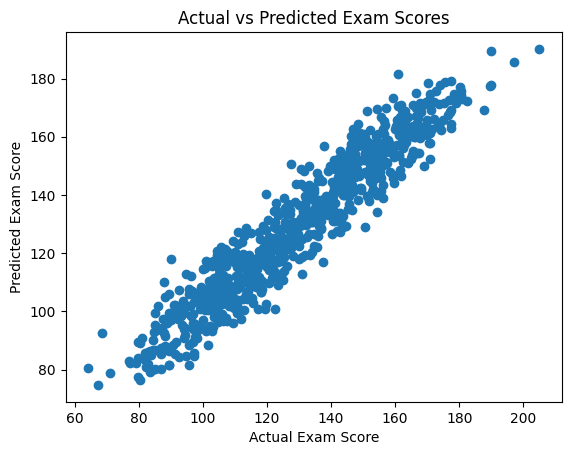

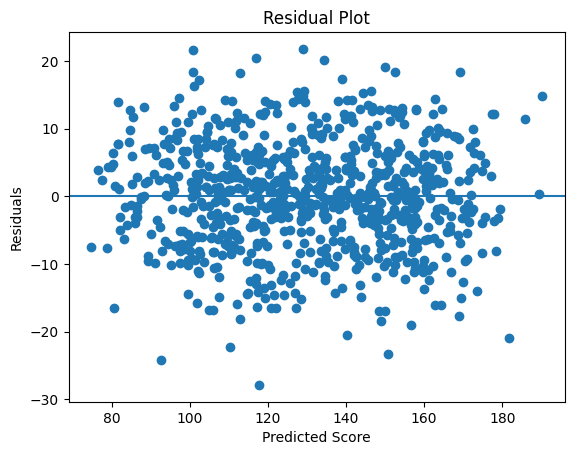

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)

n = 800

data = pd.DataFrame({
    "study_hours": np.random.randint(2, 30, n),
    "attendance": np.random.randint(50, 100, n),
    "prior_gpa": np.random.uniform(2.0, 4.0, n),
    "group_participation": np.random.uniform(1, 10, n),
    "sleep_hours": np.random.uniform(4, 9, n)
})

# Target variable: Exam Score
data["exam_score"] = (
    2.5 * data["study_hours"]
    + 0.5 * data["attendance"]
    + 12 * data["prior_gpa"]
    + 1.8 * data["group_participation"]
    + 1.2 * data["sleep_hours"]
    + np.random.normal(0, 8, n)
)

X = data.drop("exam_score", axis=1)
y = data["exam_score"]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R² Score per Fold:", r2_scores)
print("Average R²:", r2_scores.mean())

plt.figure()
plt.plot(r2_scores, marker='o')
plt.title("5-Fold Cross-Validation R² Scores")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.show()

y_pred = cross_val_predict(model, X, y, cv=kf)

plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

residuals = y - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

